In [1]:
import numpy as np
import os 
os.environ['KERAS_BACKEND'] = 'torch'
import keras
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from models_code.ffnn import ffnn
import pandas as pd

In [2]:
cpi = pd.read_csv('..\\data\\structured_data\\CPI_growth_yoy_dataframe.csv')
rgdp = pd.read_csv('..\\data\\structured_data\\RGDP_growth_dataframe.csv')
unemp = pd.read_csv('..\\data\\structured_data\\unemployment_rate_dataframe.csv')
# dropping the unwanted duplicate columns and indexes, renaming the observed value columns
cpi = cpi.drop(['Unnamed: 0'], axis = 1).rename(columns = {'OBS_VALUE': 'CPI inflation'})
rgdp = rgdp.drop(['Unnamed: 0', 'Reference area', 'TIME_PERIOD'], axis = 1).rename(columns = {'OBS_VALUE': 'RGDP growth'})
unemp = unemp.drop(['Unnamed: 0', 'Reference area', 'TIME_PERIOD'], axis = 1).rename(columns = {'OBS_VALUE': 'Unemp rate'})
# concatenating along the columns
df = pd.concat((cpi, rgdp, unemp), axis = 1)

tuning the model on vaidation data: 
best config is:
1st hidden layer neurons: 32
2nd hidden layer neurons 8
dropout rate: 0.3
batch size is: 64
minimum validation loss reached: 0.4333829879760742
reached after 8 epochs
using 16 past lags


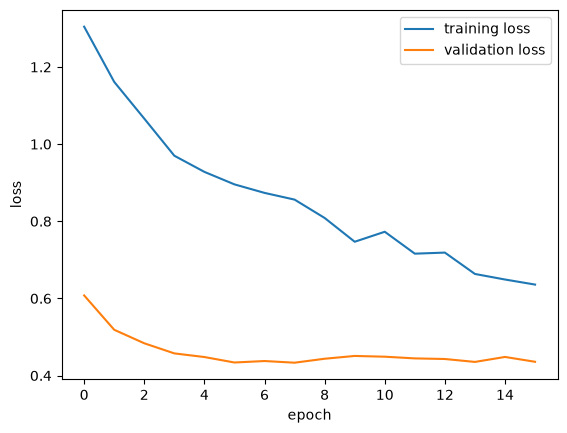

In [3]:
model = ffnn(df, column_names_to_difference = ['CPI inflation', 'Unemp rate'], train_years = [1994, 2009], 
            val_years = [2010, 2014], test_years = [2015, 2019])
model.tune_model()

In [6]:
results_df = model.rolling_origin_forecast()

starting rolling-origin forecast...
end of rolling-origin forecast...


In [9]:
results_df

,Reference area,TIME_PERIOD,Unemp rate,Forecasts
84,Australia,2015-Q1,6.202810,6.347156
85,Australia,2015-Q2,6.016903,6.189185
86,Australia,2015-Q3,6.178764,6.084279
87,Australia,2015-Q4,5.834710,6.270474
88,Australia,2016-Q1,5.796363,5.862053
...,...,...,...,...
2283,United States,2018-Q4,3.833333,3.654978
2284,United States,2019-Q1,3.866667,3.833601
2285,United States,2019-Q2,3.633333,3.708541
2286,United States,2019-Q3,3.600000,3.680828


In [10]:
results_df.to_csv('..\\data\\forecasts\\ffnn_forecasts_dataframe.csv')